In [78]:
#Libraries 
import yfinance as yf
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib import rcParams
from matplotlib.ticker import PercentFormatter 
import numpy as np

#Download data from yahoo finance
Tickers = ["AAPL", "MSFT"]

data = yf.download(
    Tickers,
    start='2022-01-01',
    end='2026-01-01'
)

prices = data["Close"]

[*********************100%***********************]  2 of 2 completed


In [60]:
returns = prices.pct_change()

In [36]:
returns 

Ticker,AAPL,MSFT
Date,,
2022-01-03,NaN,NaN
2022-01-04,-0.012691,-0.017147
2022-01-05,-0.026600,-0.038388
2022-01-06,-0.016693,-0.007902
2022-01-07,0.000988,0.000510
...,...,...
2025-12-24,0.005324,0.002403
2025-12-26,-0.001497,-0.000635
2025-12-29,0.001317,-0.001251


In [37]:
# Cummulative returns 

cummulative_returns = (1 + returns).cumprod() - 1

In [38]:
print(cummulative_returns.tail())

Ticker          AAPL      MSFT
Date                          
2025-12-24  0.535926  0.506707
2025-12-26  0.533627  0.505750
2025-12-29  0.535646  0.503867
2025-12-30  0.531831  0.505040
2025-12-31  0.524988  0.493122


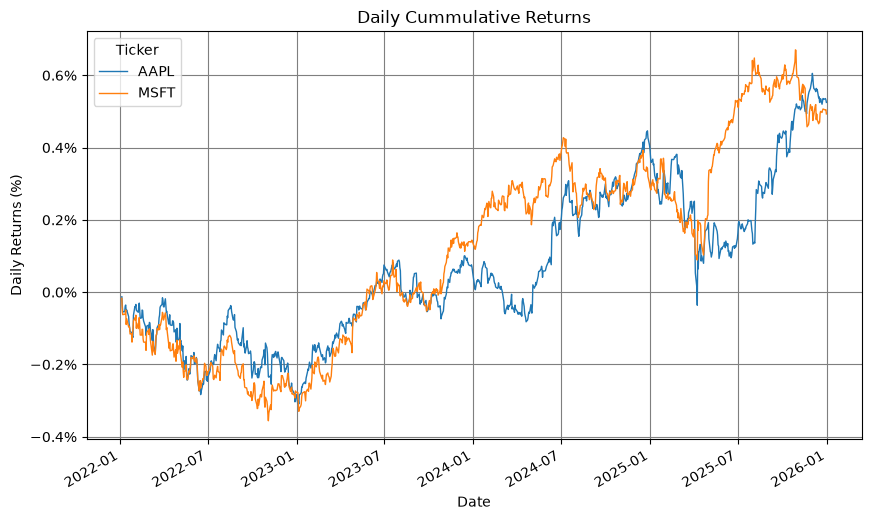

In [39]:
# Plot graph 
rcParams['figure.figsize'] = 10,6
cummulative_returns.plot(kind='line', linewidth=1)

#yFormatter 
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1))

#Plot 
plt.grid(True, color='C7')
plt.title("Daily Cummulative Returns")
plt.xlabel("Date")
plt.ylabel("Daily Returns (%)")
plt.show()


In [40]:
monthly_prices = prices.resample('ME').last()

In [41]:
monthly_returns = monthly_prices.pct_change()

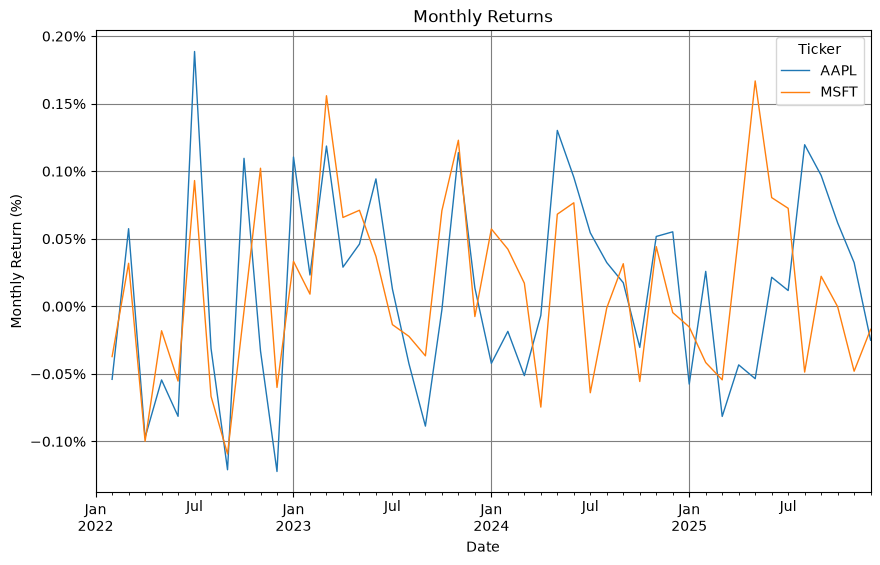

In [56]:
rcParams['figure.figsize'] = 10,6
monthly_returns.plot(kind='line', linewidth=1)

#yFormatter 
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=2))

#design 
plt.title("Monthly Returns")
plt.grid(True, color='C7')
plt.ylabel("Monthly Return (%)")
plt.xlabel("Date")
plt.show()



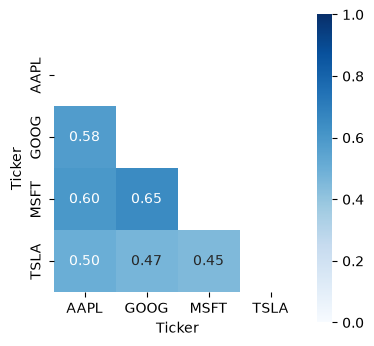

In [69]:
my_matrix = returns.corr(method="spearman").round(2)
my_mask = np.triu(np.ones_like(my_matrix, dtype=bool))

plt.figure(figsize= (4, 4))
sns.heatmap(my_matrix, cmap="Blues", vmin=0, vmax=1,
            annot=True, fmt="0.2f", square=True, mask=my_mask)

plt.show()

In [82]:
number_of_tickers = len(Tickers)
number_of_tickers

2

In [81]:
# log Returns 
log_returns = np.log(1 + prices.pct_change())

#Generate random weights 
random_weights = np.array(np.random.random(number_of_tickers))


#Generate the rebalance weights

rebalance_weights = random_weights / np.sum(random_weights)
rebalance_weights

array([0.0426496, 0.9573504])

In [86]:
#Calculate expected returns 
exp_rets = np.sum(log_returns.mean() * rebalance_weights) * 252

#Calculate the expected Volatility 
exp_vol = np.sqrt(
    np.dot(
        rebalance_weights.T,
        np.dot(
            log_returns.cov() * 252,
            rebalance_weights
        )
    )
)

# Calculate the sharpe ratio
sharpe_ratio = (exp_rets - 0.02) / exp_vol


In [91]:
import pandas as pd

In [ ]:
#Put weights into data frame to set them better 
weights_df = pd.DataFrame(data={
    'random_weights': random_weights,
    'rebalance_weights': rebalance_weights
})

print('')
print('='*80)
print('Portfolio Weights')
print(weights_df)
print('-'*80)

#Do the same 
metrics_df = pd.DataFrame(data={
    'Expected Portfolio Returns': exp_rets,
    'Expected Portfolio Volatility': exp_vol,
    'Portfolio Sharpe Ratio': sharpe_ratio
}, index=[0])

print('')
print('='*80)
print('Portfolio Metrics')
print('-'*80)
print(metrics_df)
print('-'*80)


Portfolio Weights
   random_weights  rebalance_weights
0        0.039139            0.04265
1        0.878540            0.95735
--------------------------------------------------------------------------------

Portfolio Metrics
--------------------------------------------------------------------------------
   Expected Portfolio Returns  Expected Portfolio Volatility  \
0                    0.101044                       0.263631   

   Portfolio Sharpe Ratio  
0                0.307415  
--------------------------------------------------------------------------------


In [103]:
# Daily returns
returns = prices.pct_change().dropna()

# Annual risk-free rate
risk_free_rate = 0.02
rf_daily = risk_free_rate / 252

# 30-day Rolling Sharpe Ratio
rolling_sharpe = (
    (returns - rf_daily)
    .rolling(window=30)
    .mean()
    /
    returns.rolling(window=30).std()
) * np.sqrt(252)

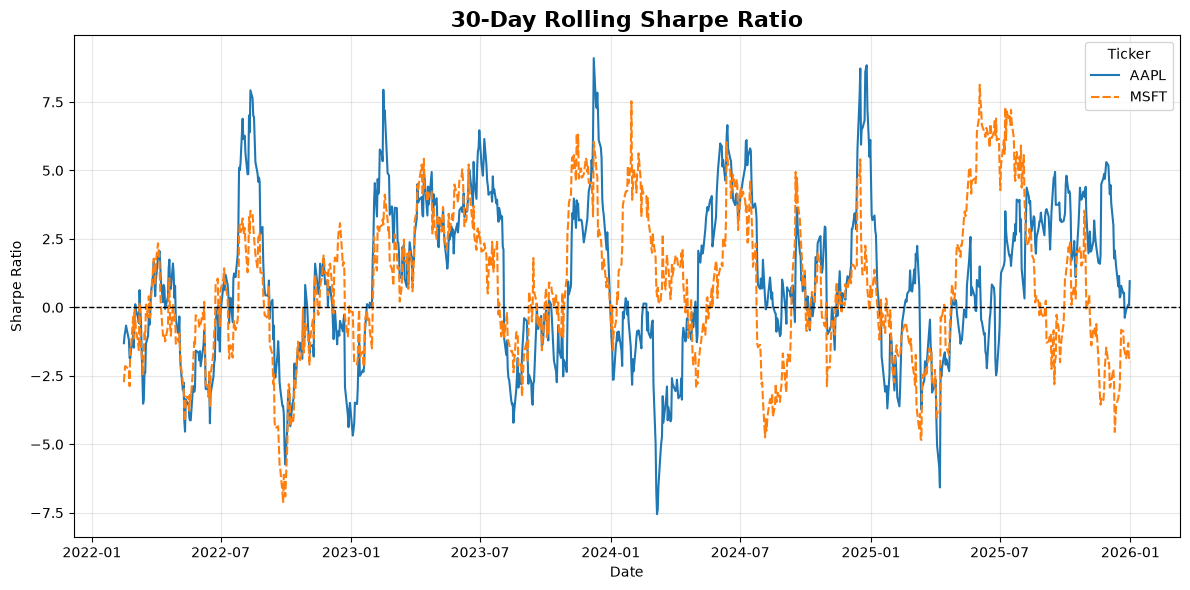

In [104]:
plt.figure(figsize=(12,6))

sns.lineplot(data=rolling_sharpe)

plt.title("30-Day Rolling Sharpe Ratio", fontsize=16, weight="bold")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.axhline(0,
            color="black",
            linestyle="--",
            linewidth=1)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()